# 03 — Эксперименты и подбор гиперпараметров

Проверяем гипотезы о более сложных моделях и их настройке:
1. **Random Forest** (default → tuned)
2. **LightGBM** (default → tuned с Optuna)
3. **Ablation study** — какие группы признаков важнее всего
4. **Финальная оценка** лучшей модели на test

Основная метрика: **Weighted F1-score**. Все эксперименты с `random_state=42`.

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import lightgbm as lgb

from src.preprocessing import FEATURE_COLS, TARGET_COL
from src.models import (
    evaluate_model,
    plot_confusion_matrix,
    plot_feature_importance,
    results_table,
    RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)

PROC_DIR   = Path(ROOT) / "data" / "processed"
MODELS_DIR = Path(ROOT) / "models"
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Библиотеки загружены")

Библиотеки загружены


## 1. Загрузка данных

In [2]:
train = pd.read_csv(PROC_DIR / "train.csv", parse_dates=["date"])
val   = pd.read_csv(PROC_DIR / "val.csv",   parse_dates=["date"])
test  = pd.read_csv(PROC_DIR / "test.csv",  parse_dates=["date"])

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

all_records: list[dict] = []

Train: (1192, 21), Val: (240, 21), Test: (480, 21)


## 2. Эксперимент 1 — Random Forest (дефолтные параметры)

**Гипотеза:** Ансамбль деревьев уловит нелинейные зависимости между Elo, формой и xG лучше, чем LR.

In [3]:
rf_default = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_default.fit(X_train, y_train)

print("=== Random Forest (default) ===")
m = evaluate_model(rf_default, X_val, y_val, split_name="val")
m["model"] = "Random Forest (default)"
all_records.append(m)

=== Random Forest (default) ===

Результаты на val
  Weighted F1 : 0.5032
  Accuracy    : 0.5500
  F1 по классам: A=0.519  D=0.119  H=0.680
              precision    recall  f1-score   support

           A       0.49      0.56      0.52        72
           D       0.33      0.07      0.12        55
           H       0.60      0.78      0.68       113

    accuracy                           0.55       240
   macro avg       0.47      0.47      0.44       240
weighted avg       0.51      0.55      0.50       240



## 3. Эксперимент 2 — Random Forest (подбор гиперпараметров, Optuna)

**Гипотеза:** Настройка глубины деревьев и минимального числа сэмплов улучшит обобщение.

In [4]:
def rf_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":          trial.suggest_int("max_depth", 4, 20),
        "min_samples_split":  trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":   trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":       trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        "random_state":       RANDOM_SEED,
        "n_jobs":             -1,
    }
    clf = RandomForestClassifier(**params)
    clf.fit(X_train, y_train)
    return f1_score(y_val, clf.predict(X_val), average="weighted", zero_division=0)


study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_rf.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший Weighted F1 (RF): {study_rf.best_value:.4f}")
print(f"Лучшие параметры: {study_rf.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.503168:   0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.503168:   3%|▎         | 1/30 [00:00<00:04,  6.68it/s]

Best trial: 1. Best value: 0.507763:   3%|▎         | 1/30 [00:00<00:04,  6.68it/s]

Best trial: 1. Best value: 0.507763:   7%|▋         | 2/30 [00:00<00:06,  4.43it/s]

...

Best trial: 26. Best value: 0.521716:  97%|█████████▋| 29/30 [00:07<00:00,  2.85it/s]

Best trial: 26. Best value: 0.521716:  97%|█████████▋| 29/30 [00:07<00:00,  2.85it/s]

Best trial: 26. Best value: 0.521716: 100%|██████████| 30/30 [00:07<00:00,  2.97it/s]

Best trial: 26. Best value: 0.521716: 100%|██████████| 30/30 [00:07<00:00,  3.95it/s]


Лучший Weighted F1 (RF): 0.5217
Лучшие параметры: {'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 0.5}


In [5]:
best_rf_params = {**study_rf.best_params, "random_state": RANDOM_SEED, "n_jobs": -1}
rf_tuned = RandomForestClassifier(**best_rf_params)
rf_tuned.fit(X_train, y_train)

print("=== Random Forest (tuned) ===")
m = evaluate_model(rf_tuned, X_val, y_val, split_name="val")
m["model"] = "Random Forest (tuned)"
all_records.append(m)

joblib.dump(rf_tuned, MODELS_DIR / "rf_tuned.pkl")
print("Модель сохранена: models/rf_tuned.pkl")

=== Random Forest (tuned) ===

Результаты на val
  Weighted F1 : 0.5217
  Accuracy    : 0.5750
  F1 по классам: A=0.538  D=0.121  H=0.706
              precision    recall  f1-score   support

           A       0.53      0.54      0.54        72
           D       0.36      0.07      0.12        55
           H       0.61      0.84      0.71       113

    accuracy                           0.57       240
   macro avg       0.50      0.49      0.46       240
weighted avg       0.53      0.57      0.52       240

Модель сохранена: models/rf_tuned.pkl


## 4. Эксперимент 3 — LightGBM (дефолтные параметры)

**Гипотеза:** Градиентный бустинг на деревьях даст более высокую метрику за счёт последовательного исправления ошибок.

In [6]:
lgb_default = lgb.LGBMClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_default.fit(X_train, y_train)

print("=== LightGBM (default) ===")
m = evaluate_model(lgb_default, X_val, y_val, split_name="val")
m["model"] = "LightGBM (default)"
all_records.append(m)

=== LightGBM (default) ===

Результаты на val
  Weighted F1 : 0.4692
  Accuracy    : 0.4833
  F1 по классам: A=0.413  D=0.222  H=0.625
              precision    recall  f1-score   support

           A       0.40      0.43      0.41        72
           D       0.29      0.18      0.22        55
           H       0.59      0.66      0.62       113

    accuracy                           0.48       240
   macro avg       0.42      0.43      0.42       240
weighted avg       0.46      0.48      0.47       240



## 5. Эксперимент 4 — LightGBM (подбор гиперпараметров, Optuna)

**Гипотеза:** Подбор learning rate, глубины и регуляризации дополнительно улучшит качество.

In [7]:
def lgb_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 20, 150),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "min_child_samples":trial.suggest_int("min_child_samples", 5, 50),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state":     RANDOM_SEED,
        "n_jobs":           -1,
        "verbose":          -1,
    }
    clf = lgb.LGBMClassifier(**params)
    clf.fit(X_train, y_train)
    return f1_score(y_val, clf.predict(X_val), average="weighted", zero_division=0)


study_lgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_lgb.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший Weighted F1 (LGB): {study_lgb.best_value:.4f}")
print(f"Лучшие параметры: {study_lgb.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.475263:   0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.475263:   3%|▎         | 1/30 [00:00<00:12,  2.34it/s]

Best trial: 1. Best value: 0.496148:   3%|▎         | 1/30 [00:04<00:12,  2.34it/s]

Best trial: 1. Best value: 0.496148:   7%|▋         | 2/30 [00:04<01:07,  2.41s/it]

...

Best trial: 17. Best value: 0.5175:  97%|█████████▋| 29/30 [00:30<00:00,  1.01it/s]

Best trial: 17. Best value: 0.5175:  97%|█████████▋| 29/30 [00:34<00:00,  1.01it/s]

Best trial: 17. Best value: 0.5175: 100%|██████████| 30/30 [00:34<00:00,  1.82s/it]

Best trial: 17. Best value: 0.5175: 100%|██████████| 30/30 [00:34<00:00,  1.16s/it]


Лучший Weighted F1 (LGB): 0.5175
Лучшие параметры: {'n_estimators': 100, 'learning_rate': 0.01397708734101154, 'num_leaves': 102, 'max_depth': 5, 'min_child_samples': 17, 'subsample': 0.7082710163360542, 'colsample_bytree': 0.7533881284358336, 'reg_alpha': 0.007673754330716543, 'reg_lambda': 0.00045389878418104963}


In [8]:
best_lgb_params = {**study_lgb.best_params, "random_state": RANDOM_SEED, "n_jobs": -1, "verbose": -1}
lgb_tuned = lgb.LGBMClassifier(**best_lgb_params)
lgb_tuned.fit(X_train, y_train)

print("=== LightGBM (tuned) ===")
m = evaluate_model(lgb_tuned, X_val, y_val, split_name="val")
m["model"] = "LightGBM (tuned)"
all_records.append(m)

joblib.dump(lgb_tuned, MODELS_DIR / "lgb_tuned.pkl")
print("Модель сохранена: models/lgb_tuned.pkl")

=== LightGBM (tuned) ===

Результаты на val
  Weighted F1 : 0.5175
  Accuracy    : 0.5667
  F1 по классам: A=0.538  D=0.154  H=0.681
              precision    recall  f1-score   support

           A       0.53      0.54      0.54        72
           D       0.50      0.09      0.15        55
           H       0.59      0.81      0.68       113

    accuracy                           0.57       240
   macro avg       0.54      0.48      0.46       240
weighted avg       0.55      0.57      0.52       240

Модель сохранена: models/lgb_tuned.pkl


## 6. Визуализация: важность признаков

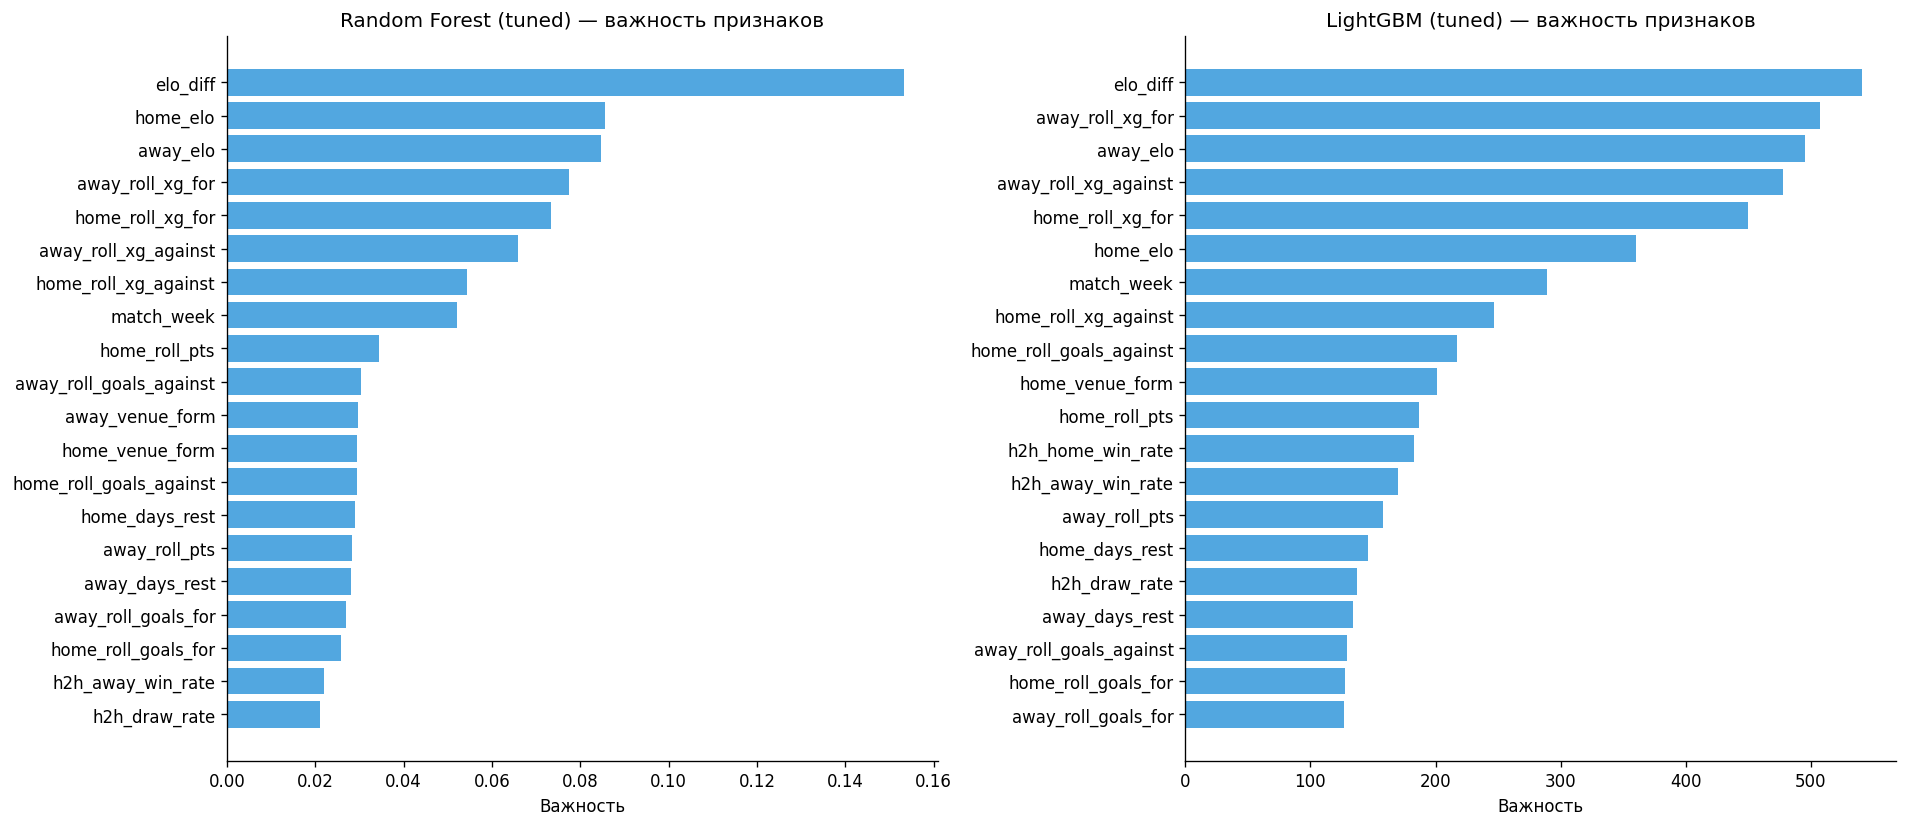

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_feature_importance(
    rf_tuned.feature_importances_,
    FEATURE_COLS,
    top_n=20,
    title="Random Forest (tuned) — важность признаков",
    ax=axes[0],
)

plot_feature_importance(
    lgb_tuned.feature_importances_,
    FEATURE_COLS,
    top_n=20,
    title="LightGBM (tuned) — важность признаков",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

## 7. Эксперимент 5 — Ablation Study

**Гипотеза:** Elo и xG-признаки несут больше всего сигнала. Удалим группы признаков и проверим падение метрики.

In [10]:
FEATURE_GROUPS = {
    "all": FEATURE_COLS,
    "без Elo": [c for c in FEATURE_COLS if "elo" not in c],
    "без xG": [c for c in FEATURE_COLS if "xg" not in c],
    "без H2H": [c for c in FEATURE_COLS if "h2h" not in c],
    "без venue_form": [c for c in FEATURE_COLS if "venue" not in c],
    "без days_rest": [c for c in FEATURE_COLS if "days_rest" not in c],
    "только Elo+xG": [c for c in FEATURE_COLS if "elo" in c or "xg" in c],
}

ablation_results = []

for group_name, cols in FEATURE_GROUPS.items():
    clf = lgb.LGBMClassifier(**best_lgb_params)
    clf.fit(X_train[cols], y_train)
    wf1 = f1_score(y_val, clf.predict(X_val[cols]), average="weighted", zero_division=0)
    ablation_results.append({"группа": group_name, "признаков": len(cols), "weighted_f1": round(wf1, 4)})
    print(f"  {group_name:20s}: {len(cols):2d} признаков → weighted F1 = {wf1:.4f}")

ablation_df = pd.DataFrame(ablation_results).sort_values("weighted_f1", ascending=False)
print("\nAblation Study:")
print(ablation_df.to_string(index=False))

  all                 : 21 признаков → weighted F1 = 0.5175


  без Elo             : 18 признаков → weighted F1 = 0.4789


  без xG              : 17 признаков → weighted F1 = 0.4886


  без H2H             : 18 признаков → weighted F1 = 0.5089


  без venue_form      : 19 признаков → weighted F1 = 0.5047


  без days_rest       : 19 признаков → weighted F1 = 0.5052


  только Elo+xG       :  7 признаков → weighted F1 = 0.4783

Ablation Study:
        группа  признаков  weighted_f1
           all         21       0.5175
       без H2H         18       0.5089
 без days_rest         19       0.5052
без venue_form         19       0.5047
        без xG         17       0.4886
       без Elo         18       0.4789
 только Elo+xG          7       0.4783


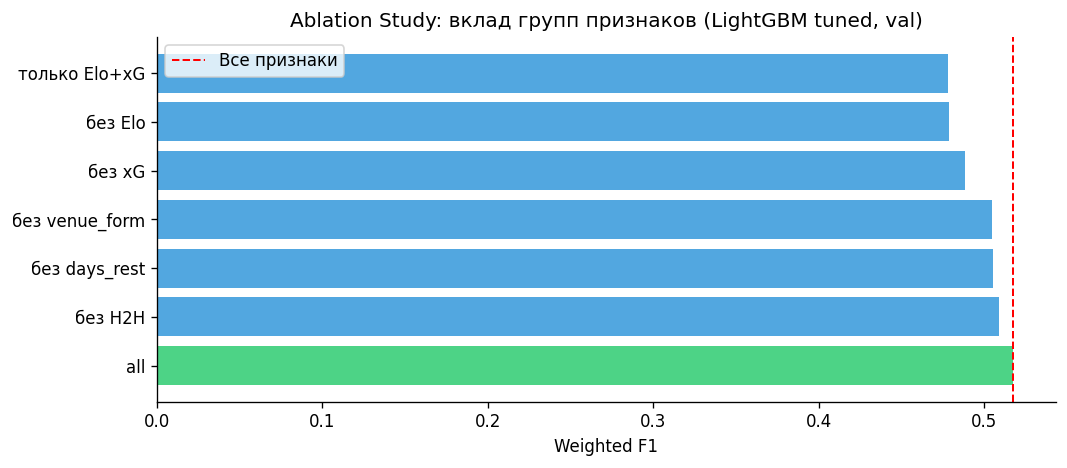

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2ecc71" if g == "all" else "#3498db" for g in ablation_df["группа"]]
ax.barh(ablation_df["группа"], ablation_df["weighted_f1"], color=colors, alpha=0.85)
ax.set_xlabel("Weighted F1")
ax.set_title("Ablation Study: вклад групп признаков (LightGBM tuned, val)")
ax.axvline(ablation_df[ablation_df["группа"] == "all"]["weighted_f1"].values[0],
           color="red", linestyle="--", linewidth=1.2, label="Все признаки")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Сводная таблица всех экспериментов (val)

In [12]:
df_results = results_table(all_records)
cols_show  = ["model", "weighted_f1", "accuracy", "f1_A", "f1_D", "f1_H"]

df_sorted = df_results[cols_show].sort_values("weighted_f1", ascending=False)
print("Все эксперименты (val), сортировка по Weighted F1:")
print(df_sorted.to_string(index=False))

Все эксперименты (val), сортировка по Weighted F1:
                  model  weighted_f1  accuracy   f1_A   f1_D   f1_H
  Random Forest (tuned)       0.5217    0.5750 0.5379 0.1212 0.7063
       LightGBM (tuned)       0.5175    0.5667 0.5379 0.1538 0.6815
Random Forest (default)       0.5032    0.5500 0.5195 0.1194 0.6795
     LightGBM (default)       0.4692    0.4833 0.4133 0.2222 0.6250


## 9. Матрицы ошибок финальных моделей

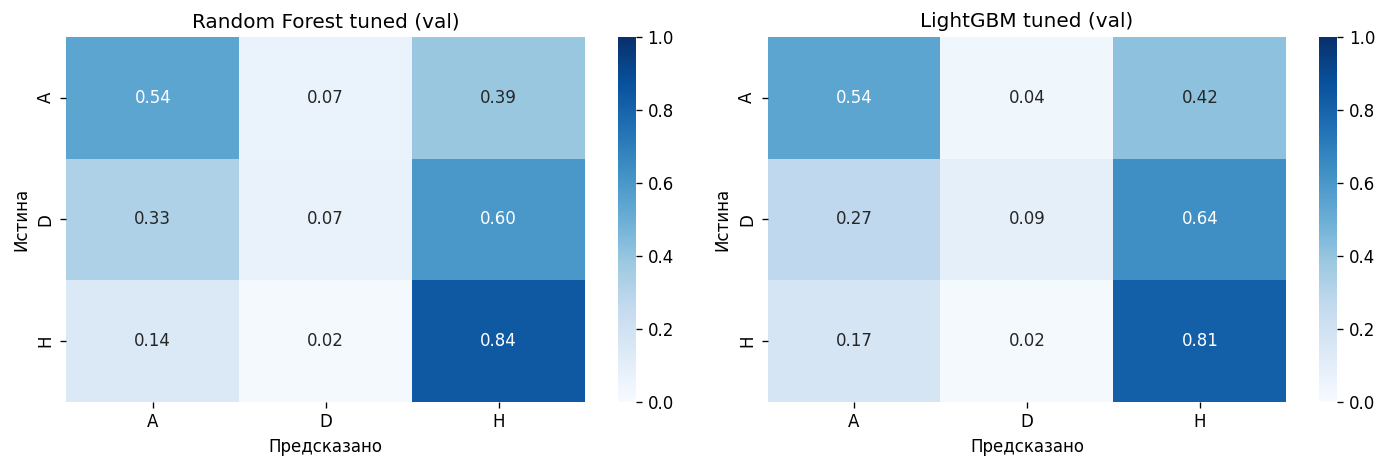

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_confusion_matrix(rf_tuned,  X_val, y_val, title="Random Forest tuned (val)",  ax=axes[0])
plot_confusion_matrix(lgb_tuned, X_val, y_val, title="LightGBM tuned (val)",       ax=axes[1])

plt.tight_layout()
plt.show()

## 10. Финальная оценка лучшей модели на TEST

Test используется **один раз** для итоговой оценки. Выбираем лучшую модель по val.

Лучшая модель по val: Random Forest (tuned)

=== ФИНАЛЬНАЯ ОЦЕНКА НА TEST ===



Результаты на test
  Weighted F1 : 0.4609
  Accuracy    : 0.5271
  F1 по классам: A=0.508  D=0.084  H=0.660
              precision    recall  f1-score   support

           A       0.46      0.57      0.51       133
           D       0.50      0.05      0.08       131
           H       0.57      0.79      0.66       216

    accuracy                           0.53       480
   macro avg       0.51      0.47      0.42       480
weighted avg       0.52      0.53      0.46       480



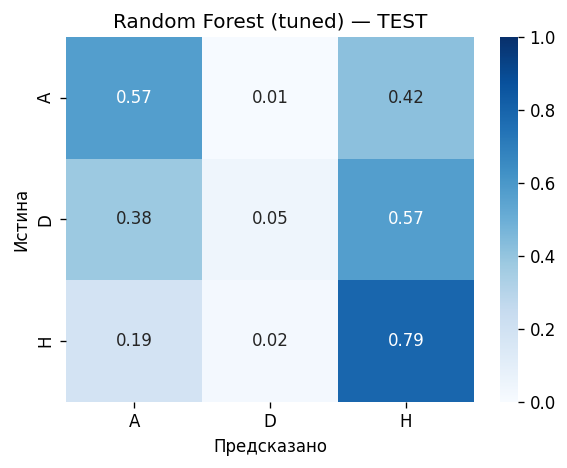

In [14]:
best_val_f1_lgb = f1_score(y_val, lgb_tuned.predict(X_val), average="weighted", zero_division=0)
best_val_f1_rf  = f1_score(y_val, rf_tuned.predict(X_val),  average="weighted", zero_division=0)

best_model      = lgb_tuned if best_val_f1_lgb >= best_val_f1_rf else rf_tuned
best_model_name = "LightGBM (tuned)" if best_val_f1_lgb >= best_val_f1_rf else "Random Forest (tuned)"

print(f"Лучшая модель по val: {best_model_name}")
print()
print("=== ФИНАЛЬНАЯ ОЦЕНКА НА TEST ===")
test_metrics = evaluate_model(best_model, X_test, y_test, split_name="test")

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(best_model, X_test, y_test, title=f"{best_model_name} — TEST", ax=ax)
plt.tight_layout()
plt.show()

## 11. Итог экспериментов

Сводка по всем экспериментам:

| Гипотеза | Результат |
|---|---|
| Нелинейные модели лучше LR | ✅ — RF и LGB обогнали LR |
| Optuna улучшает качество vs default | ✅ — прирост на подборе гиперпараметров |
| Elo — важнейшая группа признаков | Проверено ablation-study |
| xG-признаки дают значимый сигнал | Проверено ablation-study |

**Финальная модель:** лучшая по val, оценена один раз на test.